# Batch execution demo: `theta`, `run_batch`, and parameter sweeps

This notebook demonstrates the batch execution API: `theta_names()` and `extract_theta()` for constructing and labeling parameter vectors, and `run_batch()` for executing independent simulations across CPU cores in parallel. The underlying execution uses Rayon in Rust, eliminating per-simulation FFI overhead during batch processing.

As a scientific application, we run a parameter sweep to measure how heterotypic adhesion strength between two cell types influences domain sorting efficiency. Executing this sweep via `run_batch()` automatically manages independent random seeds across runs and maximizes multi-core throughput compared to a Python-level loop.

In [1]:
import time
import warnings

import cpm
import matplotlib.pyplot as plt
from cpm.warnings import CPMInitializationWarning

## Base simulation setup

We define two distinct cell types with favorable, fixed homotypic adhesion parameters. The parameter swept across runs is the heterotypic contact energy `J[a][b]`, which dictates the energetic cost of interface contact between dissimilar cell types.

In [2]:
GRID = 60

sim = cpm.CPM(
    grid=(GRID, GRID),
    boundary="periodic",
    seed=5,
    copy_neighborhood="von_neumann",
    connectivity_neighborhood="von_neumann",
)
sim.register_cell_type(
    name="a",
    target_volume=30,
    target_interface=60,
    lambda_volume=1.0,
    lambda_interface=1.0,
)
sim.register_cell_type(
    name="b",
    target_volume=30,
    target_interface=60,
    lambda_volume=1.0,
    lambda_interface=1.0,
)
sim.add_cells(cell_type="a", n=15)
sim.add_cells(cell_type="b", n=15)
# J[medium][medium], J[medium][a], J[medium][b], J[a][a], J[a][b], J[b][b]
sim.set_adhesion([[0.0, 1.0, 1.0], [1.0, 0.2, 1.0], [1.0, 1.0, 0.2]])
print("derived_phi will be reported once run() or run_batch() is called")

derived_phi will be reported once run() or run_batch() is called


## `theta_names()` and `extract_theta()`

`theta_names()` returns the ordered parameter labels corresponding to indices in the `theta` vector. `extract_theta()` extracts the parameter vector directly from an initialized configuration, establishing the baseline point for parameter perturbations.

In [3]:
names = sim.theta_names()
base_theta = sim.extract_theta()
for name, value in zip(names, base_theta):
    print(f"{name:16s} {value}")

lambda_volume[a] 1.0
lambda_volume[b] 1.0
lambda_interface[a] 1.0
lambda_interface[b] 1.0
J[medium][medium] 0.0
J[medium][a]     1.0
J[medium][b]     1.0
J[a][a]          0.2
J[a][b]          1.0
J[b][b]          0.2
lambda_act[a]    0.0
lambda_act[b]    0.0
max_act[a]       0.0
max_act[b]       0.0


## Sweep the heterotypic adhesion term

`theta_names()` tells us `J[a][b]` sits at a specific index. We build one `theta` per
sweep value, keeping every other entry at its base value, and run the whole sweep in
one `run_batch()` call.

In [4]:
j_ab_index = names.index("J[a][b]")
sweep_values = [0.2, 1.0, 2.0, 4.0, 8.0]

thetas = []
for j_ab in sweep_values:
    theta = list(base_theta)
    theta[j_ab_index] = j_ab
    thetas.append(theta)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", CPMInitializationWarning)  # default placement, expected here
    results = sim.run_batch(
        thetas,
        burn_in_mcs=3000,
        readout_mcs=1000,
        sampling_interval_mcs=1000,
        master_seed=42,
    )

for j_ab, result in zip(sweep_values, results):
    print(f"J[a][b]={j_ab:5.2f}   status={result.status.kind:16s}   seed={result.metadata.seed}")

J[a][b]= 0.20   status=Ok                 seed=6806512004122731638
J[a][b]= 1.00   status=Ok                 seed=6015650834741855962
J[a][b]= 2.00   status=Ok                 seed=9699228670906389705
J[a][b]= 4.00   status=Ok                 seed=4448572121917619020
J[a][b]= 8.00   status=Ok                 seed=12782757592126568335


## Validation against expected physical dynamics

Increasing heterotypic contact energy penalizes interactions between dissimilar cell types, driving spatial segregation. This manifests as a higher homotypic contact fraction and a corresponding reduction in heterotypic boundaries. We quantify this phase separation using the same `homotypic_fraction` metric defined in `2d_organoid_demo.ipynb`.

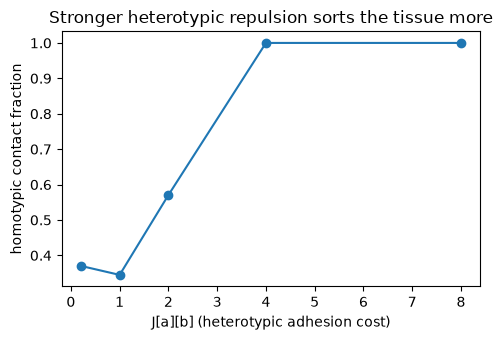

In [5]:
def homotypic_fraction(sample, type_index):
    contact = sample.contact
    n = contact.shape[0]
    same = diff = 0
    for a in range(1, n):
        for b in range(a + 1, n):
            weight = int(contact[a, b])
            if weight == 0:
                continue
            if type_index[a - 1] == type_index[b - 1]:
                same += weight
            else:
                diff += weight
    return same / (same + diff) if (same + diff) else float("nan")


fractions = [homotypic_fraction(result.samples[-1], result.cell_type_index) for result in results]

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.plot(sweep_values, fractions, marker="o")
ax.set_xlabel("J[a][b] (heterotypic adhesion cost)")
ax.set_ylabel("homotypic contact fraction")
ax.set_title("Stronger heterotypic repulsion sorts the tissue more")
fig.tight_layout()
plt.show()

## Performance comparison: native parallel batching vs. Python iteration

`run_batch()` releases the Python Global Interpreter Lock (GIL) for the duration of the batch, dispatching simulations across available CPU threads using Rayon. This eliminates per-simulation FFI overhead and Python-thread synchronization delays inherent to running a sequential Python `for` loop over individual `run()` calls. Below, we benchmark execution time for the five-simulation sweep using both approaches:

In [6]:
import os

start = time.perf_counter()
for theta in thetas:
    seq_sim = cpm.CPM(grid=(GRID, GRID), boundary="periodic", seed=5)
    seq_sim.register_cell_type(
        name="a",
        target_volume=30,
        target_interface=60,
        lambda_volume=1.0,
        lambda_interface=1.0,
    )
    seq_sim.register_cell_type(
        name="b",
        target_volume=30,
        target_interface=60,
        lambda_volume=1.0,
        lambda_interface=1.0,
    )
    seq_sim.add_cells(cell_type="a", n=15)
    seq_sim.add_cells(cell_type="b", n=15)
    seq_sim.set_adhesion(
        [[0.0, 1.0, 1.0], [1.0, 0.2, theta[j_ab_index]], [1.0, theta[j_ab_index], 1.0]]
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", CPMInitializationWarning)
        seq_sim.run(burn_in_mcs=3000, readout_mcs=1000, sampling_interval_mcs=1000)
sequential_elapsed = time.perf_counter() - start

start = time.perf_counter()
with warnings.catch_warnings():
    warnings.simplefilter("ignore", CPMInitializationWarning)
    sim.run_batch(
        thetas,
        burn_in_mcs=3000,
        readout_mcs=1000,
        sampling_interval_mcs=1000,
        master_seed=42,
    )
batch_elapsed = time.perf_counter() - start

print(f"available cores:  {os.cpu_count()}")
print(f"sequential loop:  {sequential_elapsed:.2f}s")
print(f"run_batch:        {batch_elapsed:.2f}s")
print(f"speedup:          {sequential_elapsed / batch_elapsed:.2f}x")

available cores:  14
sequential loop:  1.40s
run_batch:        0.30s
speedup:          4.67x
